### **1. Distribuzioni di probabilità**
Genera 1000 valori casuali da una distribuzione gamma con parametro di forma pari a 1.
Suggerimento: il parametro di forma viene passato come primo argomento quando si "congela" la distribuzione.

Traccia l’istogramma del campione e sovrapponi la PDF della distribuzione.

Stima il parametro di forma dal campione usando il metodo fit.

Extra:
Le distribuzioni hanno molti metodi utili. Esplorali usando il completamento automatico con il tasto TAB.

Traccia la funzione di distribuzione cumulativa (CDF).

Calcola la varianza.

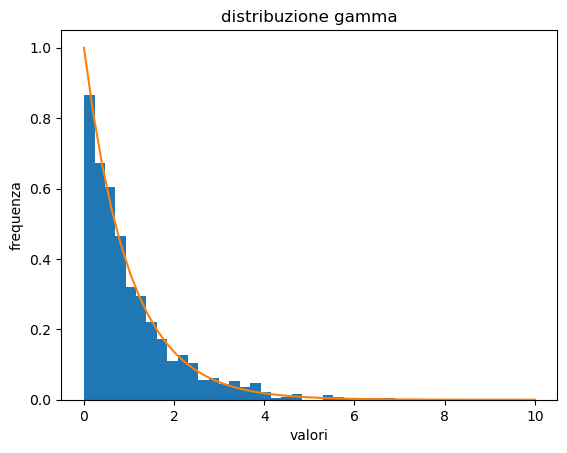

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

dist=sp.stats.gamma(1)
valori=dist.rvs(size=1000)
plt.hist(valori,bins=30,density=True,label="gamma")

plt.xlabel("valori")

plt.ylabel("frequenza")
plt.title("distribuzione gamma")
x=np.linspace(0,10)
plt.plot(x,dist.pdf(x),label="pdf")
plt.show()

In [3]:
forma,loc,scale=sp.stats.gamma.fit(valori)

print(forma)
print(loc)
print(scale)

0.9884580860229079
0.003984299399904136
1.0490871630442569


Text(0.5, 1.0, 'Gamma')

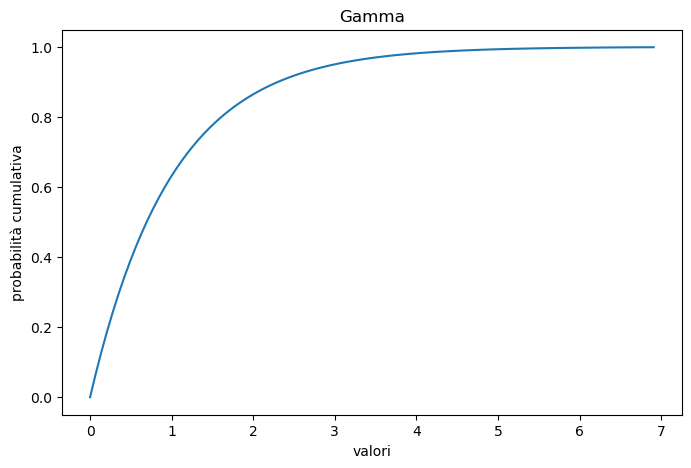

In [4]:
x=np.linspace(0,max(valori),100)
plt.figure(figsize=(8, 5))
plt.plot(x, dist.cdf(x), label="CDF")
plt.xlabel("valori")
plt.ylabel("probabilità cumulativa")
plt.title("Gamma")

In [5]:
var=np.var(valori)
var

np.float64(1.0992319173968634)

### **2. Fitta i dati**
Prova a fittare i dati sottostanti con le migliori curve, calcola il MAE e l'RMSE
Esercizio 

MAE temp max: 2.5659340659340644
RMSE temp max: 2.8954475273464007
MAE temp min: 6.358844858844857
RMSE temp min: 7.419480578092521


Text(0, 0.5, 'Temp')

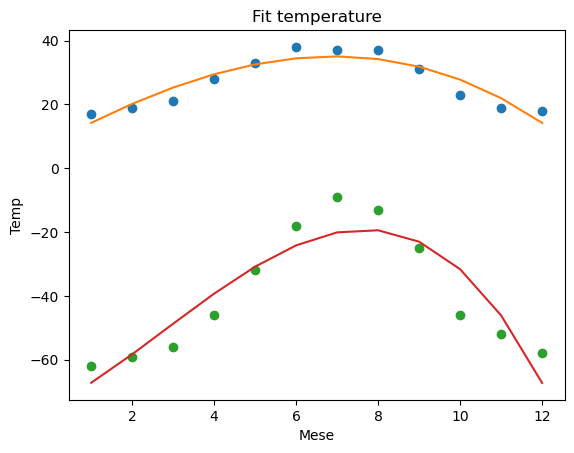

In [8]:
import numpy as np
temp_max = np.array([17, 19, 21, 28, 33, 38, 37, 37, 31, 23, 19, 18])
temp_min = np.array([-62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58])
import matplotlib.pyplot as plt

x=np.arange(1, 13)
grado=3

coefmax=np.polyfit(x, temp_max, grado)
fitmax=np.poly1d(coefmax)
coefmin = np.polyfit(x, temp_min, grado)
fitmin = np.poly1d(coefmin)
predmax = fitmax(x)
predmin = fitmin(x)

maemax=np.mean(np.abs(temp_max-predmax))
rmsemax=np.sqrt(np.mean((temp_max-predmax) ** 2))
maemin=np.mean(np.abs(temp_min-predmin))
rmsemin=np.sqrt(np.mean((temp_min-predmin) ** 2))

print("MAE temp max:", maemax)
print("RMSE temp max:", rmsemax)
print("MAE temp min:", maemin)
print("RMSE temp min:", rmsemin)


plt.plot(x, temp_max, "o", label="Temp max")
plt.plot(x, predmax, label="Fit max")
plt.plot(x, temp_min, "o", label="Temp min")
plt.plot(x, predmin, label="Fit min")
plt.title("Fit temperature")
plt.xlabel("Mese")
plt.ylabel("Temp")

### **3. Modello di regressione lineare dei seguenti dati**

 Calcola un modello di regressione lineare delle colonne mpg e disp del famoso dataset mtcars.

Dove: 

mpg = Miles Per Gallon → miglia per gallone, cioè una misura del consumo di carburante. Più alto è il valore, più efficiente è l’auto.

disp = Displacement → cilindrata del motore, in pollici cubici (cubic inches). Rappresenta il volume totale dei cilindri del motore. Più è alto, maggiore è la potenza potenziale del motore (ma anche il consumo).

In [63]:
import pandas as pd
from scipy import stats

# Load dataset from URL
df = pd.read_csv('https://gist.githubusercontent.com/seankross/a412dfbd88b3db70b74b/raw/5f23f993cd87c283ce766e7ac6b329ee7cc2e1d1/mtcars.csv')

# Display the dataframe
df


,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
5,Valiant,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1
6,Duster 360,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4
7,Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2
8,Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2
9,Merc 280,19.2,6,167.6,123,3.92,3.440,18.30,1,0,4,4


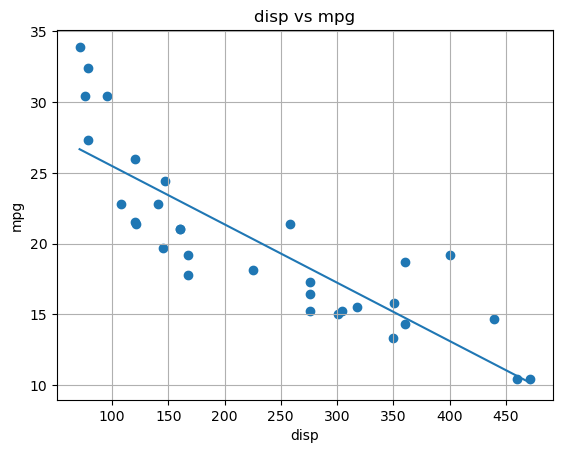

In [68]:
x=df["disp"]
y=df["mpg"]

risultato=stats.linregress(x, y)
df["mpg_pred"] =risultato.intercept+risultato.slope*df["disp"]

plt.scatter(df["disp"], df["mpg"], label="Dati reali")
x_linea=np.linspace(df["disp"].min(), df["disp"].max(), 100)
y_linea=risultato.intercept+risultato.slope*x_linea

plt.plot(x_linea, y_linea, label="Reg")
plt.xlabel("disp")
plt.ylabel("mpg")
plt.title("disp vs mpg")
plt.grid(True)